# TD N°6 – Arbres de Décision
## Machine Learning & Text Mining

## Partie 1 – Calcul de l'Entropie

**Q1. Rôle de `to_numpy()`** : Convertit le DataFrame pandas en tableau NumPy (ndarray), permettant l'indexation matricielle comme `S[:,-1]`.

**Q2. Résultat de `set(S[:,-1])`** : `{'C1', 'C2'}` — ensemble des classes uniques (sans doublons).

**Q3. Résultat de `list(S[:,-1])`** : `['C1', 'C1', 'C2', 'C2']` — liste conservant tous les éléments avec répétitions.

In [10]:
from numpy import *
import pandas

df = pandas.DataFrame([[0,1,'C1'],[0,0,'C1'],
                        [1,1,'C2'],[1,0,'C2']], columns=['A', 'B', 'Classes'])
df = df.to_numpy()

def Entropie(S):
    classes_distinctes = set(S[:,-1])
    classes = list(S[:,-1])
    s = 0
    for c in classes_distinctes:
        p = classes.count(c) / len(classes)
        s += p * log2(p)
    return(-1.0 * s)

# Q4 – Entropie du DataFrame de base
print('Entropie (base):', Entropie(df))  # Attendu : 1.0

Entropie (base): 1.0


In [11]:
# Q5 – Entropie = 0 : une seule classe
df_zero = pandas.DataFrame([[0,1,'C1'],[0,0,'C1'],
                              [1,1,'C1'],[1,0,'C1']], columns=['A','B','Classes']).to_numpy()
print('Entropie = 0 :', Entropie(df_zero))

# Q5 – Entropie > 1 : 3 classes equiprobables
df_sup1 = pandas.DataFrame([[0,1,'C1'],[0,0,'C1'],
                              [1,1,'C2'],[1,0,'C2'],
                              [0,1,'C3'],[1,1,'C3']], columns=['A','B','Classes']).to_numpy()
print('Entropie > 1 :', Entropie(df_sup1))  # Attendu : ~1.585

Entropie = 0 : -0.0
Entropie > 1 : 1.584962500721156


## Partie 2 – Gain d'Information

**Q6. `valeurs_attribut = list(set(S[:,numero_colon_attribut]))`** : Extrait les valeurs distinctes de l'attribut spécifié (ex: `[0, 1]` pour A ou B).

**Boucle `for e in S` (lignes 20-24)** : Pour chaque instance, récupère la valeur de l'attribut et l'ajoute au sous-ensemble correspondant dans `Si`. Ainsi `Si` contient une partition de S selon les valeurs de l'attribut.

In [12]:
def Gain_d_information(S, numero_colon_attribut):
    classes = list(set(S[:,-1]))
    valeurs_attribut = list(set(S[:,numero_colon_attribut]))
    Si = [[] for i in range(len(valeurs_attribut))]
    for e in S:
        e = list(e)
        val_attribut_pour_e = e[numero_colon_attribut]
        numero_sous_ensemble = valeurs_attribut.index(val_attribut_pour_e)
        Si[numero_sous_ensemble].append(e)
    Si = array(Si, dtype=object); som = 0
    for sous_ensemble in Si:
        sous_ensemble = array(sous_ensemble)
        som += (len(sous_ensemble)/len(S)) * Entropie(sous_ensemble)
    return(Entropie(S) - som)

# Q7 – Gain pour attributs A et B sur le DataFrame de base
print('Gain(A):', Gain_d_information(df, 0))
print('Gain(B):', Gain_d_information(df, 1))

Gain(A): 1.0
Gain(B): 0.0


In [13]:
# Q8 – Dataset Infarctus (Douleur / Inanime / Infarctus)
data_infarctus = pandas.DataFrame([
    ['poitrine','oui','oui'],
    ['ailleurs','oui','oui'],
    ['poitrine','non','oui'],
    ['poitrine','oui','oui'],
    ['ailleurs','non','oui'],
    ['poitrine','non','non'],
    ['ailleurs','non','non'],
    ['poitrine','oui','non'],
    ['ailleurs','non','non'],
    ['ailleurs','non','non']
], columns=['Douleur','Inanime','Infarctus']).to_numpy()

print('Entropie S:', Entropie(data_infarctus))
print('Gain(Douleur):', Gain_d_information(data_infarctus, 0))
print('Gain(Inanime):', Gain_d_information(data_infarctus, 1))

Entropie S: 1.0
Gain(Douleur): 0.02904940554533142
Gain(Inanime): 0.12451124978365313


## Partie 3 – Indice de GINI

In [14]:
# Q9a – Fonction GINI
def GINI(S):
    S = array(S)
    classes = list(S[:,-1])
    classes_distinctes = set(classes)
    s = 0
    for c in classes_distinctes:
        p = classes.count(c) / len(classes)
        s += p**2
    return 1 - s

# Q9b – Mesure de desordre selon un attribut (GINI)
def Mesure_desordre(S, numero_colon_attribut):
    valeurs_attribut = list(set(S[:,numero_colon_attribut]))
    Si = [[] for _ in range(len(valeurs_attribut))]
    for e in S:
        e = list(e)
        val = e[numero_colon_attribut]
        Si[valeurs_attribut.index(val)].append(e)
    desordre = 0
    for sous_ensemble in Si:
        sous_ensemble = array(sous_ensemble)
        desordre += (len(sous_ensemble)/len(S)) * GINI(sous_ensemble)
    return desordre

# Q9c – Calcul sur les DataFrames precedents
print('GINI(df):', GINI(df))
print('Desordre(df, A):', Mesure_desordre(df, 0))
print('Desordre(df, B):', Mesure_desordre(df, 1))
print()
print('GINI(infarctus):', GINI(data_infarctus))
print('Desordre(infarctus, Douleur):', Mesure_desordre(data_infarctus, 0))
print('Desordre(infarctus, Inanime):', Mesure_desordre(data_infarctus, 1))

GINI(df): 0.5
Desordre(df, A): 0.0
Desordre(df, B): 0.5

GINI(infarctus): 0.5
Desordre(infarctus, Douleur): 0.48
Desordre(infarctus, Inanime): 0.4166666666666667


## Partie 4 – Valeurs Continues

**Q10. Comment la fonction calcule la valeur de repartition ?**

La fonction trie les valeurs distinctes de l'attribut, puis teste chaque valeur `v` comme seuil de coupure : les instances avec attribut <= v vont dans `Gauche`, les autres dans `Droite`. Pour chaque seuil, elle calcule le desordre pondere `pGau*GINI(Gauche) + pDr*GINI(Droite)`. Elle retourne le seuil qui **minimise** ce desordre.

**Q11. Selection du meilleur attribut et meilleure valeur ?**

On itere sur tous les attributs, on appelle `Mesure_desordre_continue` pour chacun, et on retient l'attribut dont le desordre est **minimal** ainsi que le seuil associe. C'est ce que fait la fonction `meilleur_attribut_meilleure_valeur`.

In [15]:
def Mesure_desordre_continue(S, numero_colon_attribut):
    Bonne_mesure_desordre = +inf
    Bonne_valeur_de_repartition = 0
    valeurs_attribut = list(set(S[:,numero_colon_attribut]))
    valeurs_attribut.sort()
    Gauche = []; Droite = []
    for i in range(len(valeurs_attribut)-1):
        v = valeurs_attribut[i]; Gauche.clear(); Droite.clear()
        for e in S:
            val_attribut_pour_e = e[numero_colon_attribut]
            if val_attribut_pour_e <= v:
                Gauche.append(e)
            else:
                Droite.append(e)
        pGau = len(Gauche)/len(S)
        pDr  = len(Droite)/len(S)
        mesure = (pGau)*GINI(array(Gauche)) + (pDr)*GINI(array(Droite))
        if mesure < Bonne_mesure_desordre:
            Bonne_mesure_desordre = mesure
            Bonne_valeur_de_repartition = v
    return(Bonne_mesure_desordre, Bonne_valeur_de_repartition)

Data_train = array([[1,1,2,'oui'],[1,4,6,'oui'],[1,1,3,'oui'],[1,5,7,'non'],
                     [2,2,3,'non'],[2,6,5,'non'],[2,8,9,'non'],[2,3,3,'non']])

def meilleur_attribut_meilleure_valeur(S):
    meilleur_attribut = 0
    meilleure_val = 0
    meilleure_mesure = +inf
    for num_attribut in range(len(S[0])-1):
        mesure, valeur = Mesure_desordre_continue(S, num_attribut)
        if mesure < meilleure_mesure:
            meilleure_val = valeur
            meilleure_mesure = mesure
            meilleur_attribut = num_attribut
    return meilleur_attribut, meilleure_val

# Q12
attr, val = meilleur_attribut_meilleure_valeur(Data_train)
print(f'Meilleur attribut : colonne {attr}, Meilleure valeur de coupure : {val}')

Meilleur attribut : colonne 0, Meilleure valeur de coupure : 1


## Partie 5 – DecisionTreeClassifier (sklearn)

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Q13 – Split train/test : 6 train, 2 test
X      = Data_train[:6, 0:3].astype(float)
Y      = Data_train[:6, 3]
X_test = Data_train[6:, 0:3].astype(float)
y_test = Data_train[6:, 3]

print(f'Taille ensemble apprentissage : {len(X)}')
print(f'Taille ensemble test          : {len(X_test)}')

Taille ensemble apprentissage : 6
Taille ensemble test          : 2


In [17]:
# Q14 & Q15 – Comparaison GINI vs Entropie
clf_gini    = DecisionTreeClassifier(criterion='gini')
clf_entropy = DecisionTreeClassifier(criterion='entropy')

clf_gini.fit(X, Y)
clf_entropy.fit(X, Y)

print('=== GINI ===')
y_pred_gini = clf_gini.predict(X_test)
print('Matrice de confusion:\n', confusion_matrix(y_test, y_pred_gini))
print('Accuracy:', accuracy_score(y_test, y_pred_gini)*100, '%')

print('\n=== Entropie ===')
y_pred_entropy = clf_entropy.predict(X_test)
print('Matrice de confusion:\n', confusion_matrix(y_test, y_pred_entropy))
print('Accuracy:', accuracy_score(y_test, y_pred_entropy)*100, '%')

# Q14 : Le meilleur critere est celui avec la plus haute accuracy
# Q15 : FP et FN se lisent dans la matrice de confusion GINI
cm = confusion_matrix(y_test, y_pred_gini)
if cm.shape == (2,2):
    print(f'\nAvec GINI => FP: {cm[0,1]}, FN: {cm[1,0]}')

=== GINI ===
Matrice de confusion:
 [[2]]
Accuracy: 100.0 %

=== Entropie ===
Matrice de confusion:
 [[2]]
Accuracy: 100.0 %


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


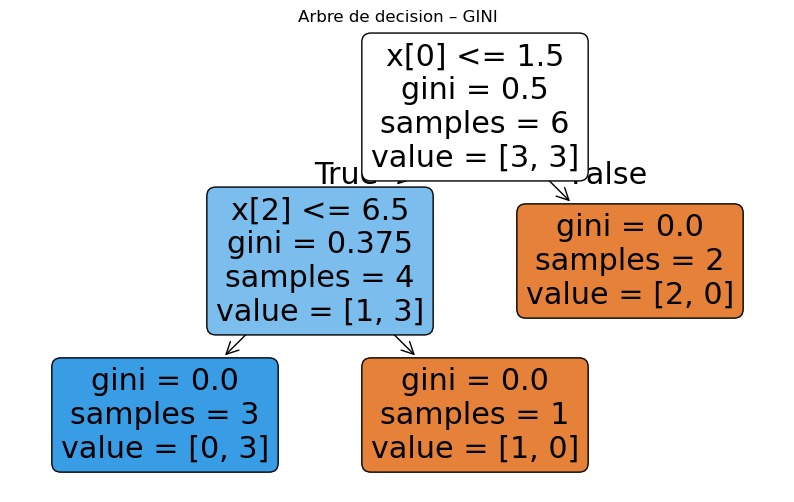

In [18]:
# Visualisation de l'arbre
try:
    import pydotplus
    from IPython.display import Image
    from io import StringIO
    from sklearn.tree import export_graphviz
    dot_data = StringIO()
    export_graphviz(clf_gini, out_file=dot_data, filled=True, rounded=True, special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    Image(graph.create_png())
except ImportError:
    from sklearn.tree import plot_tree
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,6))
    plot_tree(clf_gini, filled=True, rounded=True)
    plt.title('Arbre de decision – GINI')
    plt.show()